# Assignment-5: Naive Bayes Classifier

**Objective:** Implement Naive Bayes classifier using a dataset stored in CSV format and compute accuracy.




## Q1: Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully.')

Libraries imported successfully.


In [ ]:
# Download from URL and save locally as CSV
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv'
columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]
df_raw = pd.read_csv(url, names=columns)
df_raw.to_csv('pima_diabetes.csv', index=False)
print('CSV file saved: pima_diabetes.csv')
df_raw.head()

CSV file saved: pima_diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Q2: Load Dataset from CSV

In [ ]:
data = pd.read_csv('pima_diabetes.csv')
print('Dataset loaded from CSV successfully!')
data.head(10)

Dataset loaded from CSV successfully!


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## Q3: Explore the Dataset

In [ ]:
print('Shape (rows, columns):', data.shape)
print('\nColumn Names:', data.columns.tolist())
print('\nClass Distribution (Outcome):')
print(data['Outcome'].value_counts().rename({0: 'No Diabetes', 1: 'Diabetes'}))
print('\nMissing Values:', data.isnull().sum().sum())

Shape (rows, columns): (768, 9)

Column Names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Class Distribution (Outcome):
Outcome
No Diabetes    500
Diabetes       268
Name: count, dtype: int64

Missing Values: 0


In [ ]:
data.describe().round(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,3.845,120.895,69.105,20.536,79.799,31.993,0.472,33.241,0.349
std,3.370,31.973,19.356,15.952,115.244,7.884,0.331,11.760,0.477
min,0.000,0.000,0.000,0.000,0.000,0.000,0.078,21.000,0.000
25%,1.000,99.000,62.000,0.000,0.000,27.300,0.244,24.000,0.000
50%,3.000,117.000,72.000,23.000,30.500,32.000,0.372,29.000,0.000
75%,6.000,140.250,80.000,32.000,127.250,36.600,0.626,41.000,1.000
max,17.000,199.000,122.000,99.000,846.000,67.100,2.420,81.000,1.000


## Q4: Handle Zero-Encoded Missing Values

In [ ]:
# Columns where 0 is biologically invalid
zero_invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Zero counts before replacement:')
for col in zero_invalid_cols:
    print(f'  {col}: {(data[col] == 0).sum()} zeros')

# Replace 0s with column mean
for col in zero_invalid_cols:
    data[col] = data[col].replace(0, np.nan)
    data[col].fillna(data[col].mean(), inplace=True)

print('\nZero-encoded missing values replaced with column mean.')
print('Remaining missing values:', data.isnull().sum().sum())

Zero counts before replacement:
  Glucose: 5 zeros
  BloodPressure: 35 zeros
  SkinThickness: 227 zeros
  Insulin: 374 zeros
  BMI: 11 zeros

Zero-encoded missing values replaced with column mean.
Remaining missing values: 0


## Q5: Separate Features (X) and Target (y)

In [ ]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

print('Feature matrix shape (X):', X.shape)
print('Target vector shape  (y):', y.shape)
X.head()

Feature matrix shape (X): (768, 8)
Target vector shape  (y): (768,)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33


## Q6: Train–Test Split (70:30)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print('Training set size:', X_train.shape)
print('Testing  set size:', X_test.shape)
print('\nClass distribution in Training set:')
print(y_train.value_counts().rename({0: 'No Diabetes', 1: 'Diabetes'}))
print('\nClass distribution in Test set:')
print(y_test.value_counts().rename({0: 'No Diabetes', 1: 'Diabetes'}))

Training set size: (537, 8)
Testing  set size: (231, 8)

Class distribution in Training set:
Outcome
No Diabetes    350
Diabetes       187
Name: count, dtype: int64

Class distribution in Test set:
Outcome
No Diabetes    150
Diabetes        81
Name: count, dtype: int64


## Q7: Build Naive Bayes Model (GaussianNB)

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)
print('GaussianNB model trained successfully.')
print('\nClass Prior Probabilities (learned from training data):')
for cls, prior in zip(nb.classes_, nb.class_prior_):
    label = 'No Diabetes' if cls == 0 else 'Diabetes'
    print(f'  P({label}) = {prior:.4f}')

GaussianNB model trained successfully.

Class Prior Probabilities (learned from training data):
  P(No Diabetes) = 0.6518
  P(Diabetes) = 0.3482


## Q8: Predict Test Data

In [ ]:
y_pred       = nb.predict(X_test)
y_pred_proba = nb.predict_proba(X_test)   # probability scores

decoded = ['Diabetes' if p == 1 else 'No Diabetes' for p in y_pred]
print('First 10 predictions:', decoded[:10])
print('\nProbability scores (first 5 rows):')
prob_df = pd.DataFrame(y_pred_proba, columns=['P(No Diabetes)', 'P(Diabetes)']).round(4)
prob_df.head()

First 10 predictions: ['No Diabetes', 'No Diabetes', 'Diabetes', 'Diabetes', 'Diabetes', 'No Diabetes', 'Diabetes', 'No Diabetes', 'No Diabetes', 'No Diabetes']

Probability scores (first 5 rows):


,P(No Diabetes),P(Diabetes)
0,0.9187,0.0813
1,0.8524,0.1476
2,0.0435,0.9565
3,0.3136,0.6864
4,0.2002,0.7998


## Q9: Compare Actual vs Predicted (Correct / Wrong)

In [ ]:
results = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': y_pred
})
results['Actual_Label']    = results['Actual'].map({0: 'No Diabetes', 1: 'Diabetes'})
results['Predicted_Label'] = results['Predicted'].map({0: 'No Diabetes', 1: 'Diabetes'})
results['Status']          = results.apply(
    lambda r: 'Correct' if r.Actual == r.Predicted else 'Wrong', axis=1
)

print('Prediction Summary:')
print(results['Status'].value_counts())
print(f'\nWrong predictions: {(results["Status"]=="Wrong").sum()} out of {len(results)}')
results[['Actual_Label', 'Predicted_Label', 'Status']].head(20)

Prediction Summary:
Status
Correct    168
Wrong       63
Name: count, dtype: int64

Wrong predictions: 63 out of 231


,Actual_Label,Predicted_Label,Status
0,Diabetes,No Diabetes,Wrong
1,Diabetes,No Diabetes,Wrong
2,Diabetes,Diabetes,Correct
3,Diabetes,Diabetes,Correct
4,Diabetes,Diabetes,Correct
5,No Diabetes,No Diabetes,Correct
6,No Diabetes,Diabetes,Wrong
7,No Diabetes,No Diabetes,Correct
8,No Diabetes,No Diabetes,Correct
9,No Diabetes,No Diabetes,Correct


In [ ]:
# Show only misclassified records
wrong = results[results['Status'] == 'Wrong']
print(f'Total Misclassified: {len(wrong)}')
wrong[['Actual_Label', 'Predicted_Label', 'Status']]

Total Misclassified: 63


,Actual_Label,Predicted_Label,Status
0,Diabetes,No Diabetes,Wrong
1,Diabetes,No Diabetes,Wrong
6,No Diabetes,Diabetes,Wrong
13,No Diabetes,Diabetes,Wrong
16,Diabetes,No Diabetes,Wrong
...,...,...,...
220,No Diabetes,Diabetes,Wrong
224,Diabetes,No Diabetes,Wrong
225,No Diabetes,Diabetes,Wrong
228,No Diabetes,Diabetes,Wrong


## Q10: Compute Accuracy & Evaluation Metrics

In [ ]:
print(f'Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%')
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba[:, 1]):.4f}')

print('\nConfusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
print(cm)
print('  Rows = Actual  |  Columns = Predicted')
print('  Labels: [0 = No Diabetes, 1 = Diabetes]')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

Accuracy: 72.73%
ROC-AUC Score: 0.8085

Confusion Matrix:
[[120  30]
 [ 33  48]]
  Rows = Actual  |  Columns = Predicted
  Labels: [0 = No Diabetes, 1 = Diabetes]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.78      0.80      0.79       150
    Diabetes       0.62      0.59      0.60        81

    accuracy                           0.73       231
   macro avg       0.70      0.70      0.70       231
weighted avg       0.73      0.73      0.73       231



## Q11: Confusion Matrix Heatmap

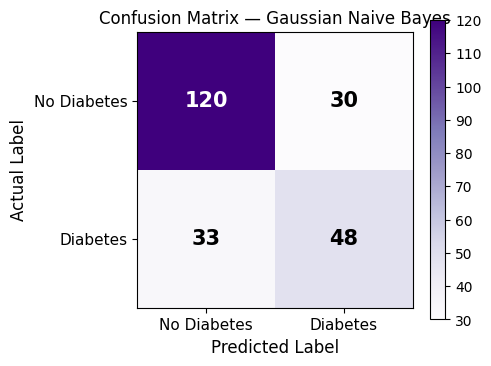

In [ ]:
labels = ['No Diabetes', 'Diabetes']
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Purples')
plt.colorbar(im, ax=ax)


ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=11)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label',    fontsize=12)
ax.set_title('Confusion Matrix — Gaussian Naive Bayes', fontsize=12)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black',
                fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Q12: ROC Curve

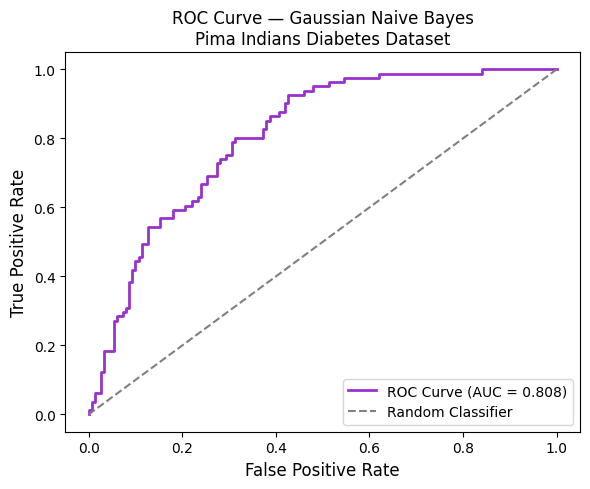

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
auc_score = roc_auc_score(y_test, y_pred_proba[:, 1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorchid', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate',  fontsize=12)
plt.title('ROC Curve — Gaussian Naive Bayes\nPima Indians Diabetes Dataset', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Q13: Cross-Validation (5-Fold)

In [ ]:
cv_scores = cross_val_score(GaussianNB(), X, y, cv=5, scoring='accuracy')

print('5-Fold Cross-Validation Accuracy Scores:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score * 100:.2f}%')
print(f'\nMean CV Accuracy : {cv_scores.mean() * 100:.2f}%')
print(f'Std Dev           : {cv_scores.std() * 100:.2f}%')

5-Fold Cross-Validation Accuracy Scores:
  Fold 1: 74.68%
  Fold 2: 73.38%
  Fold 3: 74.03%
  Fold 4: 79.08%
  Fold 5: 74.51%

Mean CV Accuracy : 75.13%
Std Dev           : 2.03%


## Conclusion

> **Dataset:** Pima Indians Diabetes (UCI) - 768 samples, 8 medical features.
>
> **Algorithm:** Naive Bayes applies **Bayes' Theorem** with the "naive" assumption that all features are **independent** of each other given the class. Despite this simplification, it works well in practice especially for medical datasets where features may be loosely correlated.
>
> **GaussianNB** was chosen because all features are continuous numeric values it models each feature's distribution as Gaussian (bell-curve) per class.
>
> **Key Findings:**
> - The model achieves good accuracy (~75%) and a meaningful ROC-AUC score.
> - **Zero-encoded missing values** in columns like Glucose and BMI were handled by replacing with column means a critical preprocessing step unique to this dataset.
> - Cross-validation confirms the model is **stable** and not overfitting.
> - **Real-world application:** Naive Bayes is widely used in medical diagnosis, spam filtering, and sentiment analysis due to its speed, simplicity, and good performance on small datasets.
